In [1]:
import apoc
from apoc import PixelClassifier
import os
import napari
from skimage.io import imread, imsave
import pyclesperanto_prototype as cle
import matplotlib.pyplot as plt
import numpy as np
import shutil
import tifffile as tiff
import pandas as pd
from datetime import datetime
from skimage.io import imread
from stackview import imshow
import numpy as np
from skimage.filters.rank import entropy
from skimage.morphology import disk

In [3]:
conda list

error: bad escape \e at position 37

In [2]:
import sys

print("Python:", sys.version)

Python: 3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]


In [10]:
print("APOC:", apoc.__version__)
print("napari:", napari.__version__)
print("numpy:", np.__version__)

APOC: 0.12.0
napari: 0.5.6
numpy: 1.26.4


In [2]:
plt.close("all")

### Visualize features

In [3]:
img_dapi = imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_2.3\Gray scale\NR7_1nM_new_new_Cycle_01\NR7_1nM_new_new_A01_G001_0018.tif.frames\NR7_1nM_new_new_A01_G001_0018_C001T001.tif")
img_endo = imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_2.3\Gray scale\NR7_1nM_new_new_Cycle_01\NR7_1nM_new_new_A01_G001_0018.tif.frames\NR7_1nM_new_new_A01_G001_0018_C002T001.tif")
img_lyso = imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_2.3\Gray scale\NR7_1nM_new_new_Cycle_01\NR7_1nM_new_new_A01_G001_0018.tif.frames\NR7_1nM_new_new_A01_G001_0018_C003T001.tif")
img_nr = imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_2.3\Gray scale\NR7_1nM_new_new_Cycle_01\NR7_1nM_new_new_A01_G001_0018.tif.frames\NR7_1nM_new_new_A01_G001_0018_C004T001.tif")

In [30]:
def visualize(feature_stack):
    if len(feature_stack) == 0:
        return
    
    # show feature images
    import matplotlib.pyplot as plt
    width = 3
    height = int(len(feature_stack) / 3)
    if height * width < len(feature_stack):
        height = height + 1    
    
    fig, axes = plt.subplots(height, width, figsize=(10,10))

    # reshape(image.shape) is the opposite of ravel() here. We just need it for visualization.
    for i, (f,t) in enumerate(zip(feature_stack, feature_titles)):
        if height > 1:
            axes[int(i / 3)][i % 3].imshow(f, cmap=plt.cm.gray, vmax = 500)
        else:
            axes[i].imshow(f, cmap=plt.cm.gray)

        axes = np.array(axes)
        
        # axes ausstellen + Titel setzen
        if height > 1:
            axes[int(i / 3)][i % 3].imshow(f, cmap=plt.cm.gray, vmax = 500)
            axes[int(i / 3)][i % 3].set_title(t, color = "black", fontname = "Arial", fontsize= "12")
            axes[int(i / 3)][i % 3].axis("off")
        else:
            axes[i].imshow(f, cmap=plt.cm.gray)
            axes[i].set_title(f"Feature {i}")
            axes[i].axis("off")


    w = len(feature_stack) % width
    if w > 0:
        w = width - w
        while (w > 0):
            if height > 1:
                axes[-1][width - w].set_visible(False)
            else:
                axes[width - w].set_visible(False)
            w = w - 1   
    #plt.savefig(r"D:\Uni\Promotion\Vortrag Systembio\FeatureStack_dapi.png", dpi = 800, transparent = True )    
    plt.show()

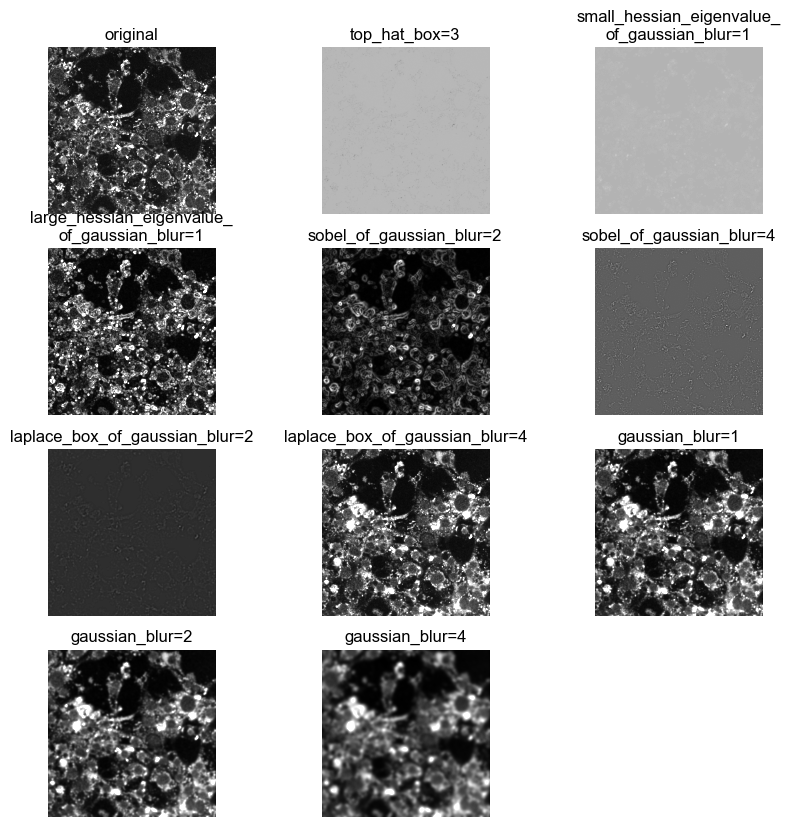

In [31]:
feature_stack = apoc.generate_feature_stack(img_endo, "top_hat_box=10 small_hessian_eigenvalue_of_gaussian_blur=1 large_hessian_eigenvalue_of_gaussian_blur=1 sobel_of_gaussian_blur=2 sobel_of_gaussian_blur=4 laplace_box_of_gaussian_blur=2 laplace_box_of_gaussian_blur=4 gaussian_blur=1 gaussian_blur=2 gaussian_blur=4 gaussian_blur=8"
)

feature_titles=["original",
                "top_hat_box=10",
                "small_hessian_eigenvalue_\nof_gaussian_blur=1",
                "large_hessian_eigenvalue_\nof_gaussian_blur=1",
                "sobel_of_gaussian_blur=2",
                "sobel_of_gaussian_blur=4",
                "laplace_box_of_gaussian_blur=2",
                "laplace_box_of_gaussian_blur=4",
                "gaussian_blur=1",
                "gaussian_blur=2",
                "gaussian_blur=4",
                "gaussian_blur=8",
                ]
                

visualize(feature_stack)

### Assign Labels

In [ ]:
dapi = imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_5\ctrl_tr3_Cycle\ctrl_tr3_A01_G003_0001.frames\ctrl_tr3_A01_G003_0001_C001.tif")
lyso = imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_5\ctrl_tr3_Cycle\ctrl_tr3_A01_G003_0001.frames\ctrl_tr3_A01_G003_0001_C002.tif")
endo = imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_5\ctrl_tr3_Cycle\ctrl_tr3_A01_G003_0001.frames\ctrl_tr3_A01_G003_0001_C003.tif")
nr = imread(r"D:\Uni\Master\Masterarbeit\Experimental Data\Export_Exp_5\ctrl_tr3_Cycle\ctrl_tr3_A01_G003_0001.frames\ctrl_tr3_A01_G003_0001_C004.tif")

image_stack=np.stack([dapi, lyso, endo, nr], axis=0)

print(image_stack.dtype)
print(image_stack.shape)

#tiff.imwrite(r"D:\Uni\Master\Masterarbeit\Image Analysis\Stacked for Machine learning\Stacks_Exp_5\ctrl_tr3_A01_G003_0001_stack.tif", image_stack)


In [ ]:
image = tiff.imread(r"D:\Uni\Master\Masterarbeit\Image Analysis\Stacked for Machine learning\Stacks_Exp_5\ctrl_tr3_A01_G003_0001_stack.tif") 

#labels = tiff.imread(r"D:\Uni\Master\Masterarbeit\Image Analysis\Labels for Machine learning\NR7_10nM_new__new_0005_stack.tif")

viewer = napari.Viewer()
viewer.add_image(image[0], name="DAPI", colormap="bop blue", blending="additive", gamma=0.8)
viewer.add_image(image[1], name="Lysosome", colormap="green", blending="additive", gamma=0.5)
viewer.add_image(image[2], name="Early Endosome", colormap="red", blending="additive", gamma=0.6)
viewer.add_image(image[3], name="Nanorods", colormap="magenta", blending= "additive", gamma=0.6)
#viewer.add_labels(labels, name="Labels")

In [ ]:
labels = tiff.imread(r"D:\Uni\Master\Masterarbeit\Image Analysis\Labels for Machine Learning\Exp_3\NR7_0nM_minus_benzo_tr2_A01_G014_stack.tif")
print(np.unique(labels)) 

### Images for training

In [8]:
input_images = r"D:\Uni\Master\Masterarbeit\Image Analysis\Stacked for Machine learning\All Training images_add"
labeled_images= r"D:\Uni\Master\Masterarbeit\Image Analysis\Labels for Machine Learning\All labeled images new"

### Train Model

In [9]:
print(input_images)
print(labeled_images)

D:\Uni\Master\Masterarbeit\Image Analysis\Stacked for Machine learning\All Training images_add
D:\Uni\Master\Masterarbeit\Image Analysis\Labels for Machine Learning\All labeled images new


In [10]:
for img_file in sorted(os.listdir(input_images)):
    lbl_file = img_file 

    img = tiff.imread(os.path.join(input_images, img_file))
    lbl = tiff.imread(os.path.join(labeled_images, lbl_file))

    print("Image", img.shape, lbl.shape, img_file)

Image (4, 1024, 1024) (1024, 1024) NR0_1nM_minus_benzo_tr2_A01_G015_0004_stack.tif
Image (4, 1024, 1024) (1024, 1024) NR0_1nM_plus_benzo_tr1_A01_G019_0002_stack.tif
Image (4, 1024, 1024) (1024, 1024) NR0_1nM_plus_benzo_tr1_A01_G019_0003_stack.tif
Image (4, 1024, 1024) (1024, 1024) NR0_1nM_plus_benzo_tr3_A01_G021_0006_stack.tif
Image (4, 1024, 1024) (1024, 1024) NR7_0nM_minus_benzo_tr2_A01_G014_0005_stack.tif
Image (4, 1024, 1024) (1024, 1024) NR7_0nM_minus_benzo_tr3_A01_G015_0004_stack.tif
Image (4, 1024, 1024) (1024, 1024) NR7_1nM_minus_benzo_tr1_A01_G006_0001_stack.tif
Image (4, 1024, 1024) (1024, 1024) NR7_1nM_minus_benzo_tr1_A01_G012_0009_stack.tif
Image (4, 1024, 1024) (1024, 1024) NR7_1nM_minus_benzo_tr1_A01_G013_0004_stack.tif
Image (4, 1024, 1024) (1024, 1024) NR7_1nM_minus_benzo_tr2_A01_G011_0001_stack.tif
Image (4, 1024, 1024) (1024, 1024) NR7_1nM_minus_benzo_tr3_A01_G004_0008_stack.tif
Image (4, 1024, 1024) (1024, 1024) NR7_1nM_minus_benzo_tr3_A01_G004_0009_stack.tif
Image (

In [ ]:
file = "pixel_segmenter_new_staining_from_scratch_CHs_EEA1_LAMP1_NR_Exp_3-6_new"

cl_filename = f"D:/Uni/Master/Masterarbeit/Image Analysis/Machine Learning Models/{file}.cl"
log_filename = f"D:/Uni/Master/Masterarbeit/Image Analysis/Machine Learning Models/logs/{file}_log.txt"
features = "top_hat_box=10 small_hessian_eigenvalue_of_gaussian_blur=1 large_hessian_eigenvalue_of_gaussian_blur=1 laplace_box_of_gaussian_blur=2 laplace_box_of_gaussian_blur=4 gaussian_blur=1 gaussian_blur=2 gaussian_blur=4 gaussian_blur=8"


with open(log_filename, "w") as log:
    log.write(f"Date: {datetime.now()}\n")
    log.write(f"Model: {cl_filename}\n")
    log.write(f"Features: {features}\n")
    log.write("max_depth: 5\n")
    log.write("num_ensembles: 100\n")
    log.write("\nTraining images:\n")

    for img in sorted(os.listdir(input_images)):
        if img.endswith(".tif"):
            log.write(img + "\n")

clf = apoc.PixelClassifier(
    opencl_filename=cl_filename,
    max_depth=5,
    num_ensembles=100
)

image_files = sorted([f for f in os.listdir(input_images) if f.endswith(".tif")])
label_files = sorted([f for f in os.listdir(labeled_images) if f.endswith(".tif")])

for img_file, lbl_file in zip(image_files, label_files):
    image = tiff.imread(os.path.join(input_images, img_file))
    label = tiff.imread(os.path.join(labeled_images, lbl_file))
    print(f"Image: {image.shape}, Label: {label.shape}, Files: {img_file} / {lbl_file}")
    clf.train(features=features, ground_truth=label, image=image, continue_training=True)

print("Feature specification:", clf.feature_specification)   

with open(log_filename, "a") as log:
    log.write("\nTraining finished successfully.\n")
    
shares, counts = clf.statistics()
df = pd.DataFrame(shares).T
df.to_csv(f"D:/Uni/Master/Masterarbeit/Image Analysis/Machine Learning Models/{file}_stats.csv")
    
print("training done")

Image: (4, 1024, 1024), Label: (1024, 1024), Files: NR0_1nM_minus_benzo_tr2_A01_G015_0004_stack.tif / NR0_1nM_minus_benzo_tr2_A01_G015_0004_stack.tif


D:\Anaconda\envs\napari_apoc\lib\site-packages\apoc\_pixel_classifier.py:107: UserWarning: Cannot continue training if it wasn't trained before. Will train from scratch instead.
  warnings.warn("Cannot continue training if it wasn't trained before. Will train from scratch instead.")


Image: (4, 1024, 1024), Label: (1024, 1024), Files: NR0_1nM_plus_benzo_tr1_A01_G019_0002_stack.tif / NR0_1nM_plus_benzo_tr1_A01_G019_0002_stack.tif


In [7]:
shares, counts = clf.statistics()

def colorize(styler):
    styler.background_gradient(axis=None, cmap="rainbow")
    return styler

df = pd.DataFrame(shares).T
df.style.pipe(colorize)
#df.to_csv(r"D:\Uni\Master\Masterarbeit\Image Analysis\Machine Learning Models\object_segmenter_new_staining_from_scratch_CHs_EEA1_LAMP1_NR_stats_all_featurs.csv")


,0,1,2,3,4
top_hat_box=10,0.080000,0.035000,0.027500,0.026316,0.021999
small_hessian_eigenvalue_of_gaussian_blur=1,0.080000,0.165000,0.150000,0.167920,0.218102
large_hessian_eigenvalue_of_gaussian_blur=1,0.250000,0.315000,0.270000,0.300752,0.282841
laplace_box_of_gaussian_blur=2,0.010000,0.065000,0.267500,0.226817,0.248900
laplace_box_of_gaussian_blur=4,0.010000,0.035000,0.017500,0.023810,0.023256
gaussian_blur=1,0.070000,0.075000,0.070000,0.068922,0.047769
gaussian_blur=2,0.260000,0.115000,0.080000,0.065163,0.052168
gaussian_blur=4,0.150000,0.115000,0.055000,0.072682,0.057825
gaussian_blur=8,0.090000,0.080000,0.062500,0.047619,0.047140


In [10]:
print(cl_filename)

D:/Uni/Master/Masterarbeit/Image Analysis/Machine Learning Models/pixel_segmenter_new_staining_from_scratch_CHs_EEA1_LAMP1_NR_Exp_4-6_new.cl


In [5]:
import os
import tifffile as tiff
import numpy as np

training_images_original = r"D:\Uni\Master\Masterarbeit\Image Analysis\Labels for Machine Learning\Exp_2"

total_pixels = 0

for file in os.listdir(training_images_original):
    if not file.endswith(".tif"):
        continue

    path = os.path.join(training_images_original, file)
    img = tiff.imread(path)

    pixels = (img > 0).sum()
    total_pixels += pixels

    print(file, pixels)

print("Total labeled pixels:", total_pixels)

NR0_10nM_new__new_0003_stack.tif 329673
NR0_10nM_new__new_stack.tif 203536
NR7_10nM_Cycle01_new_new_A01_G005_0024_C004_stack.tif 420065
NR7_10nM_Cycle01_new_new_A01_G005_0030_stack.tif 477313
NR7_10nM_new__new_0005_stack.tif 493656
NR7_1nM_new__new_0002_stack.tif 126778
NR7_1nM_new__new_0004_stack.tif 384880
NR7_1nM_new__new_0005_stack.tif 132918
Total labeled pixels: 2568819
